# Executive Summary: Why February Revenue Dropped -13.5%

## TL;DR

- Revenue fell from 39,119.5 EUR to 33,827.0 EUR (-5,292.5 EUR, -13.5%) between January and February 2026.
- One root cause explains almost all of it: the __paid_social__ acquisition channel lost 69% of its new user registrations in February, which cascaded into an order-volume collapse in that channel.
- Because __paid_social__ was both a large channel (44% of January revenue) and skewed toward the most expensive packages, its collapse *mechanically* dragged down the blended average order value and made it look like a broad shift away from expensive tariffs and a general AOV problem. It wasn't - every other channel grew.
- It's a top-of-funnel volume problem, not a conversion-quality problem: users who did register through __paid_social__ converted to a paid order about as often as before.
- Calendar effects, refunds, country mix, platform mix, and repeat-purchase behavior were all checked and ruled out as material causes.

This notebook brings together the findings from __00__-__02__ into one summary, states the caveats plainly, and closes with concrete next steps.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.db import get_connection, load_query  # noqa: E402

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PAID_SOCIAL_COLOR = "#d62728"
OTHER_COLOR = "#4c72b0"
TOTAL_COLOR = "#55a868"

con = get_connection()

## Root-cause waterfall

One chart tying the whole investigation together: starting from January revenue, how much did __paid_social__ subtract, and how much did every other channel add back, to land on February's total?

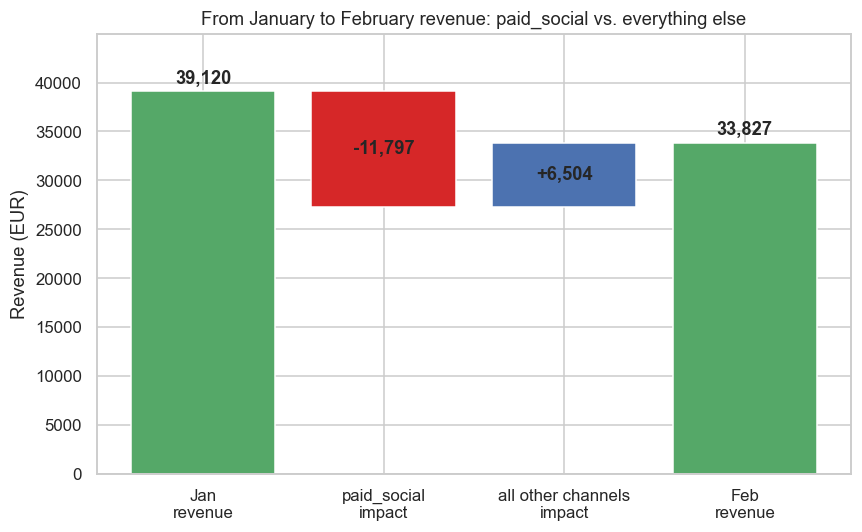

In [2]:
isolation = con.execute(load_query("03_revenue_drop_hypotheses.sql", "paid_social_isolation")).fetchdf()
pivot = isolation.pivot(index="channel_group", columns="order_month", values="revenue_eur")
jan_total = pivot.sum().iloc[0]
feb_total = pivot.sum().iloc[1]
paid_social_delta = pivot.loc["paid_social"].iloc[1] - pivot.loc["paid_social"].iloc[0]
other_delta = pivot.loc["all_other_channels"].iloc[1] - pivot.loc["all_other_channels"].iloc[0]

labels = ["Jan\nrevenue", "paid_social\nimpact", "all other channels\nimpact", "Feb\nrevenue"]
values = [jan_total, paid_social_delta, other_delta, feb_total]
starts = [0, jan_total + paid_social_delta, jan_total + paid_social_delta, 0]
bar_values = [jan_total, abs(paid_social_delta), abs(other_delta), feb_total]
colors = [TOTAL_COLOR, PAID_SOCIAL_COLOR, OTHER_COLOR, TOTAL_COLOR]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, bar_values, bottom=starts, color=colors)
for i, (label, start, val, real_val) in enumerate(zip(labels, starts, bar_values, values)):
    y = start + val + 400 if i in (0, 3) else start + val / 2
    text = f"{real_val:,.0f}" if i in (0, 3) else f"{real_val:+,.0f}"
    ax.text(i, y, text, ha="center", va="bottom" if i in (0, 3) else "center", fontweight="bold")
ax.set_ylabel("Revenue (EUR)")
ax.set_title("From January to February revenue: paid_social vs. everything else")
ax.set_ylim(0, jan_total * 1.15)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "03_revenue_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

## Hypothesis scorecard

| # | Hypothesis | Verdict | Key evidence |
|---|---|---|---|
| H1 | Shorter February (fewer days) | Ruled out | Orders/day rose 57.7 -> 62.1, nearly offsetting the 3 missing days |
| H2 | More refunds | Ruled out | Refund rate +0.45 pp, only ~82 EUR |
| H3 | Regional demand shift | Ruled out | Broad -0.8 to -2.4 pp per country, no outlier |
| H4 | Platform mix shift | Ruled out | Evenly spread -3.6 to -5.0 pp across iOS/Android/web |
| H5 | Fewer repeat purchases | Ruled out | Repeat revenue flat (-7.5 EUR) |
| H6 | Orders vs. AOV | Confirmed | AOV effect (-4,177.9 EUR) ~4x the volume effect (-1,114.6 EUR) |
| H7 | One acquisition channel underperformed | Confirmed | __paid_social__ revenue -68.5% (-30.2 pp); every other channel grew |
| H8 | Tariff mix shifted to cheaper plans | Confound, not independent | Signal vanishes once __paid_social__ is excluded (all packages grew) |
| H9 | Onboarding/conversion quality dropped | Ruled out | 14-day conversion for __paid_social__ ~flat (13.4% -> 12.5%) |
| H10 | Acquisition *volume* dropped for __paid_social__ | Confirmed root cause | Registrations -69.1% (3,400 -> 1,050) |

## Limitations & caveats

- Synthetic data. This dataset was generated for a take-home exercise, not pulled from a live warehouse. Patterns like the identical within-month revenue ramp-up in both January and February are very likely generation artifacts; conclusions about *within*-month timing should be read with that in mind. The cross-channel, cross-tariff structure of the drop looks intentional and is the focus of this analysis.
- Short window. Only 2 months of data - no way to check whether __paid_social__'s February dip is a one-off, a trend, or normal month-to-month noise for that channel.
- No marketing spend/campaign data. We can see that __paid_social__ registrations collapsed, but not *why* (budget cut, targeting change, tracking break, seasonality). That requires data this export doesn't include.
- Small-sample segments. Channel x tariff cells (H8/H9 in notebook 01) can have as few as single-digit order counts; percentage changes there are directional, not statistically rigorous.
- Correlation, not proof. The chain "acquisition volume down -> revenue down" is a strong, consistent, quantified association across every cut of the data we tried - but confirming true causation (vs. e.g. a shared external cause) would need experiment data or spend logs.

## Recommendations

1. Talk to marketing/growth about __paid_social__ first. This is the single highest-leverage lever: recovering __paid_social__ registrations to January's level would recover most of the -13.5% drop. Check campaign status, budget pacing, and audience/targeting changes for February.
2. Audit tracking/attribution for __paid_social__ before assuming it's a real drop in demand - a broken pixel or UTM change could silently misattribute registrations to another channel (e.g. __organic__, which grew).
3. Don't chase the AOV/tariff-mix "problem" as if it were separate - it's a symptom of (1), not an independent lever. Fixing tariff mix directly (e.g. promoting expensive plans) won't address the root cause.
4. Keep an eye on __organic__ conversion (9.38% -> 7.03%), which is a real, second-order dip worth a follow-up look once the __paid_social__ volume issue is addressed.
5. Operationally, add a lightweight weekly check on registrations-by-channel and 14-day-conversion-by-channel side by side - this analysis shows they can move in opposite directions, and only looking at revenue would have hidden that.